In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

# Paths
sample_path = Path(
    "../data/processed/AD_1_LS/AD_1_LS"
)

results_path = Path("../outputs/results")
figures_path = Path("../outputs/figures")

# Load processed spatial data
adata = __import__("scanpy").read_h5ad(
    results_path / "AD_1_LS_processed.h5ad"
)

# Load H&E image
image_path = sample_path / "spatial/tissue_hires_image.png"
img = Image.open(image_path).convert("RGB")

# Load scale factor
import json

with open(sample_path / "spatial/scalefactors_json.json") as f:
    scalefactors = json.load(f)

scale = scalefactors["tissue_hires_scalef"]

print("Image size:", img.size)
print("Dataset shape:", adata.shape)
print("Scale factor:", scale)

Image size: (1924, 2000)
Dataset shape: (188, 21587)
Scale factor: 0.2


In [2]:
from PIL import ImageStat

# Convert image to NumPy array
image_array = np.array(img)

# Spot coordinates in image-resolution pixels
x_coords = (
    adata.obs["pixel_col"].to_numpy() * scale
).astype(int)

y_coords = (
    adata.obs["pixel_row"].to_numpy() * scale
).astype(int)

patch_size = 32
half_patch = patch_size // 2

features = []

for x, y in zip(x_coords, y_coords):

    x1 = max(0, x - half_patch)
    x2 = min(image_array.shape[1], x + half_patch)

    y1 = max(0, y - half_patch)
    y2 = min(image_array.shape[0], y + half_patch)

    patch = image_array[y1:y2, x1:x2]

    mean_rgb = patch.mean(axis=(0, 1))
    std_rgb = patch.std(axis=(0, 1))

    brightness = mean_rgb.mean()

    features.append([
        *mean_rgb,
        *std_rgb,
        brightness
    ])

image_features = pd.DataFrame(
    features,
    columns=[
        "mean_R",
        "mean_G",
        "mean_B",
        "std_R",
        "std_G",
        "std_B",
        "brightness"
    ],
    index=adata.obs_names
)

print(image_features.shape)
print(image_features.head())

(188, 7)
                        mean_R      mean_G      mean_B      std_R      std_G  \
AAAGTGTGATTTATCT-1  201.265625  187.759766  220.932617  30.905124  29.710992   
AAAGTTGACTCCCGTA-1  187.768555  173.896484  214.456055  23.550190  28.657171   
AACACACGCTCGCCGC-1  194.288086  181.853516  219.535156  18.048438  17.324342   
AACCCTACTGTCAATA-1  189.847656  177.244141  214.784180  29.607594  34.639225   
AACCGCTAAGGGATGC-1  223.816406  210.348633  229.889648  18.146417  14.931633   

                        std_B  brightness  
AAAGTGTGATTTATCT-1  12.817390  203.319336  
AAAGTTGACTCCCGTA-1  14.713873  192.040365  
AACACACGCTCGCCGC-1   7.858908  198.558919  
AACCCTACTGTCAATA-1  20.386435  193.958659  
AACCGCTAAGGGATGC-1   8.567433  221.351562  


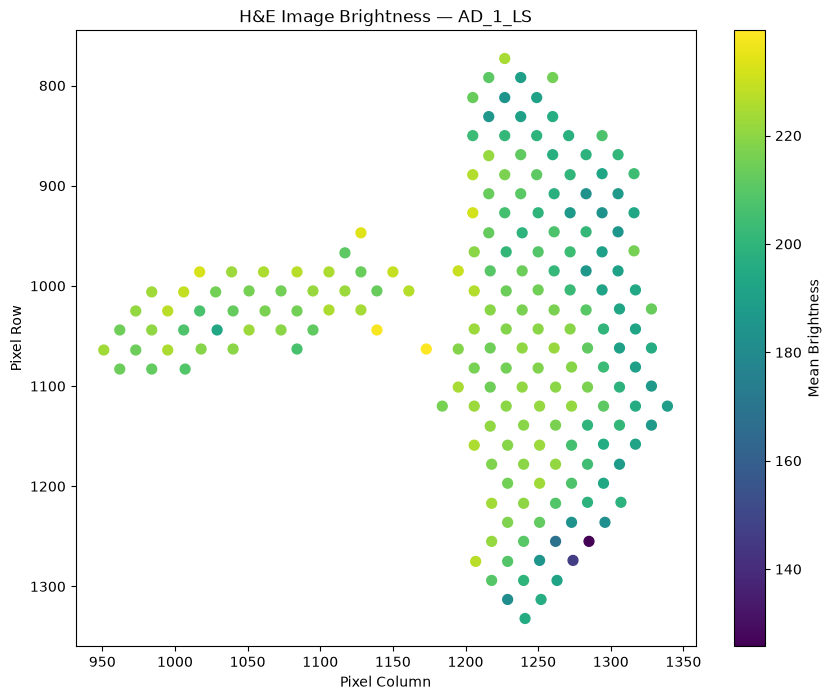

In [3]:
# Visualize mean brightness across spatial spots

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    x_coords,
    y_coords,
    c=image_features["brightness"],
    cmap="viridis",
    s=50
)

plt.gca().invert_yaxis()
plt.colorbar(scatter, label="Mean Brightness")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.title("H&E Image Brightness — AD_1_LS")
plt.show()

In [4]:
# Save extracted image features

image_features.to_csv(
    results_path / "AD_1_LS_image_features.csv"
)

print("Image features saved!")

Image features saved!
